# General E(2)-Equivariant Steerable CNN

## Utils

In [1]:
# Utils for colab, no need to run if running locally
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copytree('/content/drive/MyDrive/characters', '/content/characters', dirs_exist_ok=True)

Mounted at /content/drive


'/content/characters'

In [ ]:
# Utils to transform segmented character pngs into 28x28
import os
from pathlib import Path
from PIL import Image, ImageOps

def pad_to_square(im, fill=(0, 0, 0)):
    # If image has alpha, composite on fill background first to avoid halos
    if im.mode in ("RGBA", "LA"):
        bg = Image.new("RGBA", im.size, fill + (255,))
        im = Image.alpha_composite(bg, im).convert("RGB")
    elif im.mode != "RGB":
        im = im.convert("RGB")

    w, h = im.size
    if w == h:
        return im

    # Pad to square on longer side
    size = max(w, h)
    # ImageOps.pad can both pad and resample while centering
    # Using 'expand' style padding by first scaling to not exceed size
    ratio = min(size / w, size / h)
    new_w, new_h = int(round(w * ratio)), int(round(h * ratio))
    im_resized = im.resize((new_w, new_h), Image.BICUBIC)
    delta_w, delta_h = size - new_w, size - new_h
    padding = (delta_w // 2, delta_h // 2, delta_w - delta_w // 2, delta_h - delta_h // 2)
    return ImageOps.expand(im_resized, padding, fill=fill)

def process_dir(input_dir, output_dir, target_size=(28, 28), fill=(0, 0, 0), overwrite=False):
    input_dir = Path(input_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
    count, skipped = 0, 0

    for p in input_dir.iterdir():
        if not p.is_file() or p.suffix.lower() not in exts:
            skipped += 1
            continue

        out_path = output_dir / (p.stem + ".png")  # unified output format
        if out_path.exists() and not overwrite:
            skipped += 1
            continue

        try:
            with Image.open(p) as im:
                sq = pad_to_square(im, fill=fill)
                out = sq.resize(target_size, Image.BICUBIC)
                out.save(out_path, optimize=True)
                count += 1
        except Exception as e:
            print(f"Failed {p.name}: {e}")
            skipped += 1

    print(f"Done. Saved: {count}, skipped: {skipped}, output: {output_dir}")

In [ ]:
process_dir("../data/splitCharacters", "../data/paddedCharacters", target_size=(28, 28), fill=(255, 255, 255), overwrite=False)

In [ ]:
# Utils to train-test split the segmented characters
import os
import random
from pathlib import Path
import shutil

def split_dir(
    src_dir,
    out_dir,
    train_ratio=0.8,
    seed=42,
    exts=None,     # e.g., {".jpg", ".png"} to filter
    move=True      # True: move; False: copy
):
    src = Path(src_dir)
    out = Path(out_dir)
    (out / "train").mkdir(parents=True, exist_ok=True)
    (out / "test").mkdir(parents=True, exist_ok=True)

    # Collect files (optionally filter by extension)
    files = [p for p in src.iterdir() if p.is_file() and (exts is None or p.suffix.lower() in exts)]

    # Reproducible random split
    rng = random.Random(seed)
    rng.shuffle(files)

    n_train = int(len(files) * train_ratio)
    train_files = files[:n_train]
    test_files = files[n_train:]

    transfer = shutil.move if move else shutil.copy2

    for f in train_files:
        transfer(str(f), str(out / "train" / f.name))
    for f in test_files:
        transfer(str(f), str(out / "test" / f.name))

    print(f"Total: {len(files)}, train: {len(train_files)}, test: {len(test_files)}")

In [ ]:
split_dir("../data/paddedCharacters", "../data/characters", train_ratio=0.8, seed=42, exts={".jpg", ".png"}, move=False)

## Model

In [3]:
import torch

from e2cnn import gspaces
from e2cnn import nn

In [4]:
class C8SteerableCNN(torch.nn.Module):

    def __init__(self, n_classes=36):

        super(C8SteerableCNN, self).__init__()

        # the model is equivariant under rotations by 45 degrees, modelled by C8
        self.r2_act = gspaces.Rot2dOnR2(N=8)

        # the input image is a scalar field, corresponding to the trivial representation
        in_type = nn.FieldType(self.r2_act, [self.r2_act.trivial_repr])

        # we store the input type for wrapping the images into a geometric tensor during the forward pass
        self.input_type = in_type

        # convolution 1
        # first specify the output type of the convolutional layer
        # we choose 24 feature fields, each transforming under the regular representation of C8
        out_type = nn.FieldType(self.r2_act, 24*[self.r2_act.regular_repr])
        self.block1 = nn.SequentialModule(
            nn.MaskModule(in_type, 29, margin=1),
            nn.R2Conv(in_type, out_type, kernel_size=7, padding=1, bias=False),
            nn.InnerBatchNorm(out_type),
            nn.ReLU(out_type, inplace=True)
        )

        # convolution 2
        # the old output type is the input type to the next layer
        in_type = self.block1.out_type
        # the output type of the second convolution layer are 48 regular feature fields of C8
        out_type = nn.FieldType(self.r2_act, 48*[self.r2_act.regular_repr])
        self.block2 = nn.SequentialModule(
            nn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            nn.InnerBatchNorm(out_type),
            nn.ReLU(out_type, inplace=True)
        )
        self.pool1 = nn.SequentialModule(
            nn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=2)
        )

        # convolution 3
        # the old output type is the input type to the next layer
        in_type = self.block2.out_type
        # the output type of the third convolution layer are 48 regular feature fields of C8
        out_type = nn.FieldType(self.r2_act, 48*[self.r2_act.regular_repr])
        self.block3 = nn.SequentialModule(
            nn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            nn.InnerBatchNorm(out_type),
            nn.ReLU(out_type, inplace=True)
        )

        # convolution 4
        # the old output type is the input type to the next layer
        in_type = self.block3.out_type
        # the output type of the fourth convolution layer are 96 regular feature fields of C8
        out_type = nn.FieldType(self.r2_act, 96*[self.r2_act.regular_repr])
        self.block4 = nn.SequentialModule(
            nn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            nn.InnerBatchNorm(out_type),
            nn.ReLU(out_type, inplace=True)
        )
        self.pool2 = nn.SequentialModule(
            nn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=2)
        )

        # convolution 5
        # the old output type is the input type to the next layer
        in_type = self.block4.out_type
        # the output type of the fifth convolution layer are 96 regular feature fields of C8
        out_type = nn.FieldType(self.r2_act, 96*[self.r2_act.regular_repr])
        self.block5 = nn.SequentialModule(
            nn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            nn.InnerBatchNorm(out_type),
            nn.ReLU(out_type, inplace=True)
        )

        # convolution 6
        # the old output type is the input type to the next layer
        in_type = self.block5.out_type
        # the output type of the sixth convolution layer are 64 regular feature fields of C8
        out_type = nn.FieldType(self.r2_act, 64*[self.r2_act.regular_repr])
        self.block6 = nn.SequentialModule(
            nn.R2Conv(in_type, out_type, kernel_size=5, padding=1, bias=False),
            nn.InnerBatchNorm(out_type),
            nn.ReLU(out_type, inplace=True)
        )
        self.pool3 = nn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=1, padding=0)

        self.gpool = nn.GroupPooling(out_type)

        # number of output channels
        c = self.gpool.out_type.size

        # Fully Connected
        self.fully_net = torch.nn.Sequential(
            torch.nn.Linear(c, 64),
            torch.nn.BatchNorm1d(64),
            torch.nn.ELU(inplace=True),
            torch.nn.Linear(64, n_classes),
        )

    def forward(self, input: torch.Tensor):
        # wrap the input tensor in a GeometricTensor
        # (associate it with the input type)
        x = nn.GeometricTensor(input, self.input_type)

        # apply each equivariant block

        # Each layer has an input and an output type
        # A layer takes a GeometricTensor in input.
        # This tensor needs to be associated with the same representation of the layer's input type
        #
        # The Layer outputs a new GeometricTensor, associated with the layer's output type.
        # As a result, consecutive layers need to have matching input/output types
        x = self.block1(x)
        x = self.block2(x)
        x = self.pool1(x)

        x = self.block3(x)
        x = self.block4(x)
        x = self.pool2(x)

        x = self.block5(x)
        x = self.block6(x)

        # pool over the spatial dimensions
        x = self.pool3(x)

        # pool over the group
        x = self.gpool(x)

        # unwrap the output GeometricTensor
        # (take the Pytorch tensor and discard the associated representation)
        x = x.tensor

        # classify with the final fully connected layers)
        x = self.fully_net(x.reshape(x.shape[0], -1))

        return x

In [6]:
from torch.utils.data import Dataset
from torchvision.transforms import RandomRotation
from torchvision.transforms import Pad
from torchvision.transforms import Resize
from torchvision.transforms import ToTensor
from torchvision.transforms import Compose

import numpy as np

from PIL import Image

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Dataset

In [7]:
from pathlib import Path

class CaptchaDataset(Dataset):

    def __init__(self, root_dir, mode = 'train', transform=None):
        assert mode in ["train", "test"]

        self.transform = transform
        self.dir = Path(root_dir) / mode
        self.files = sorted(self.dir.glob("*.png"))
        if not self.files:
            raise FileNotFoundError(f"No PNG files found in {self.dir}")

        self.char2label = {}
        self.label2char = {}
        for i, char in enumerate(sorted(list(set([f.stem.split("_")[0] for f in self.files])))):
          self.char2label[char] = i
          self.label2char[i] = char

    def __getitem__(self, index):
        path = self.files[index]

        # Filename format: "<label>_<index>.png"
        label = self.char2label[path.stem.split("_")[0]]
        image = Image.open(path).convert("L")
        if self.transform is not None:
            image = self.transform(image)
        return image, label

    def __len__(self):
        return len(self.files)

# original images are 28x28 grayscale
# images are padded to have shape 29x29.
# this allows to use odd-size filters with stride 2 when downsampling a feature map in the model
pad = Pad((0, 0, 1, 1), fill=0)

# to reduce interpolation artifacts (e.g. when testing the model on rotated images),
# we upsample an image by a factor of 3, rotate it and finally downsample it again
resize1 = Resize(87)
resize2 = Resize(29)

totensor = ToTensor()

## Train

In [8]:
model = C8SteerableCNN().to(device)

/usr/local/lib/python3.12/dist-packages/e2cnn/nn/modules/r2_conv/basisexpansion_singleblock.py:80: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /pytorch/aten/src/ATen/native/IndexingUtils.h:29.)
  full_mask[mask] = norms.to(torch.uint8)


In [10]:
# build a sample test set to check images and labels are loaded correctly
raw_test_set = CaptchaDataset('/content/characters', mode='test')
raw_test_set.label2char

{0: '0',
 1: '1',
 2: '2',
 3: '3',
 4: '4',
 5: '5',
 6: '6',
 7: '7',
 8: '8',
 9: '9',
 10: 'a',
 11: 'b',
 12: 'c',
 13: 'd',
 14: 'e',
 15: 'f',
 16: 'g',
 17: 'h',
 18: 'i',
 19: 'j',
 20: 'k',
 21: 'l',
 22: 'm',
 23: 'n',
 24: 'o',
 25: 'p',
 26: 'q',
 27: 'r',
 28: 's',
 29: 't',
 30: 'u',
 31: 'v',
 32: 'w',
 33: 'x',
 34: 'y',
 35: 'z'}

4643


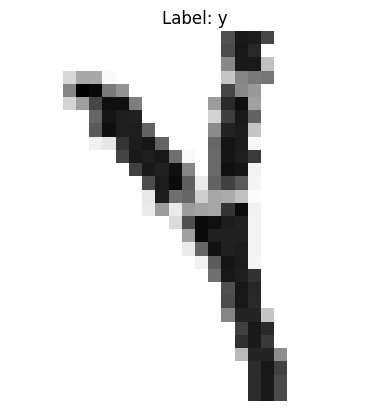

2763


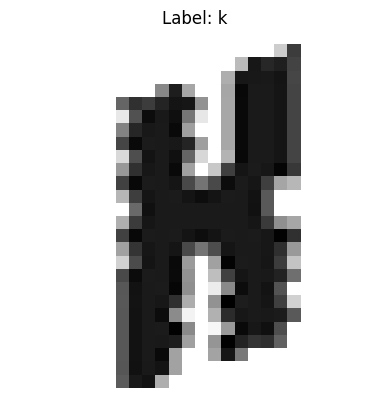

In [11]:
import random
import matplotlib.pyplot as plt

for _ in range(2):
    idx = random.randint(0, len(raw_test_set) - 1)
    image, label = raw_test_set[idx]
    print(idx)
    label_char = raw_test_set.label2char[label]

    plt.imshow(image, cmap="gray")
    plt.title(f"Label: {label_char}")
    plt.axis("off")
    plt.show()

In [12]:
train_transform = Compose([
    pad,
    resize1,
    # RandomRotation(180, resample=Image.BILINEAR, expand=False),
    resize2,
    totensor,
])

train_set = CaptchaDataset('/content/characters', mode='train', transform=train_transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)

In [13]:
test_transform = Compose([
    pad,
    totensor,
])
test_set = CaptchaDataset('/content/characters', mode='test', transform=test_transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=64)

loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5, weight_decay=1e-5)

In [14]:
for epoch in range(16):
    model.train()
    for i, (x, t) in enumerate(train_loader):
        if i % 20 == 0:
          print("Batch", i)
        optimizer.zero_grad()

        x = x.to(device)
        t = t.to(device)

        y = model(x)

        loss = loss_function(y, t)

        loss.backward()

        optimizer.step()

    if epoch % 5 == 0:
        total = 0
        correct = 0
        with torch.no_grad():
            model.eval()
            for i, (x, t) in enumerate(test_loader):

                x = x.to(device)
                t = t.to(device)

                y = model(x)

                _, prediction = torch.max(y.data, 1)
                total += t.shape[0]
                correct += (prediction == t).sum().item()
        print(f"epoch {epoch} | test accuracy: {correct/total*100.}")


Batch 0
Batch 20
Batch 40
Batch 60
Batch 80
Batch 100
Batch 120
Batch 140
Batch 160
Batch 180
Batch 200
Batch 220
Batch 240
Batch 260
Batch 280
Batch 300
epoch 0 | test accuracy: 48.940111133978185
Batch 0
Batch 20
Batch 40
Batch 60
Batch 80
Batch 100
Batch 120
Batch 140
Batch 160
Batch 180
Batch 200
Batch 220
Batch 240
Batch 260
Batch 280
Batch 300
Batch 0
Batch 20
Batch 40
Batch 60
Batch 80
Batch 100
Batch 120
Batch 140
Batch 160
Batch 180
Batch 200
Batch 220
Batch 240
Batch 260
Batch 280
Batch 300
Batch 0
Batch 20
Batch 40
Batch 60
Batch 80
Batch 100
Batch 120
Batch 140
Batch 160
Batch 180
Batch 200
Batch 220
Batch 240
Batch 260
Batch 280
Batch 300
Batch 0
Batch 20
Batch 40
Batch 60
Batch 80
Batch 100
Batch 120
Batch 140
Batch 160
Batch 180
Batch 200
Batch 220
Batch 240
Batch 260
Batch 280
Batch 300
Batch 0
Batch 20
Batch 40
Batch 60
Batch 80
Batch 100
Batch 120
Batch 140
Batch 160
Batch 180
Batch 200
Batch 220
Batch 240
Batch 260
Batch 280
Batch 300
epoch 5 | test accuracy: 76.4354

In [15]:
torch.save(model.state_dict(), "ecnn.pt")

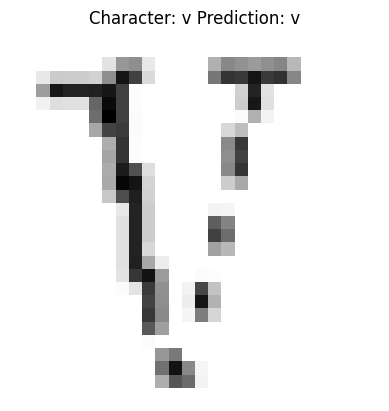

In [25]:
idx = random.randint(0, len(raw_test_set) - 1)
image, label = raw_test_set[idx]
label_char = raw_test_set.label2char[label]
x = test_transform(image).reshape(1, 1, 29, 29)

with torch.no_grad():
    model.eval()
    x = x.to(device)
    y = model(x)
    _, prediction = torch.max(y.data, 1)

plt.imshow(image, cmap="gray")
plt.title(f"Character: {label_char} Prediction: {raw_test_set.label2char[prediction.item()]}")
plt.axis("off")
plt.show()